In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("../../data/fifa_world_cup_2026_player_performance.csv")
print("Dataset loaded successfully")
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])
df.head()

Dataset loaded successfully
Rows: 54600
Columns: 75


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,match_id,match_date,stadium,city,opponent_team,tournament_stage,match_result,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,RB Salzburg,4384884,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,72,0,0,0,0,0.00,0.00,0,15,26,0.59,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,4,0.83,0,1,0,0,7.8,0.7,26.5,13,23,81.9,5.6,50.9,3.3,48.2,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,Chelsea,4918927,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,90,0,0,0,0,0.01,0.00,1,35,40,0.89,1,0,1,0,0,1,3,1,2,0,2,5,0,1,0,0,0,0,0.00,0,0,0,0,10.4,1.1,29.0,19,17,85.5,5.7,55.9,37.9,29.4,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,AIK,125015698,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,73,1,0,2,0,0.08,0.07,2,72,85,0.85,0,0,3,0,1,1,0,0,1,2,4,2,0,0,0,0,0,0,0.00,0,0,0,0,8.8,1.3,33.7,30,19,88.8,8.3,82.9,79.8,78.6,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,PSV Eindhoven,11805512,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,80,1,1,5,2,0.00,0.21,0,12,19,0.67,1,0,0,0,1,1,1,0,3,0,1,3,0,1,0,0,0,0,0.00,0,0,0,0,9.6,1.0,32.1,26,19,89.2,6.9,67.5,47.3,6.9,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,Juventus,13325174,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,79,0,0,1,0,0.00,0.00,1,33,44,0.76,2,1,0,0,1,3,0,2,1,2,4,6,0,0,0,0,0,0,0.00,0,0,0,0,7.5,0.7,30.5,23,18,73.6,5.7,55.4,33.0,75.6,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [2]:
print("Duplicate rows:",df.duplicated().sum()); print("\nMissing values:"); display(df.isna().sum().to_frame("Missing Values"))

Duplicate rows: 0

Missing values:


,Missing Values
player_id,0
player_name,0
age,0
nationality,0
team,0
...,...
total_goals_tournament,0
total_assists_tournament,0
total_minutes_tournament,0
player_of_match_awards,0


In [3]:
clean=df.copy(); clean["match_date"]=pd.to_datetime(clean["match_date"],errors="coerce"); print("Prepared shape:",clean.shape); print("Remaining missing values:",int(clean.isnull().sum().sum()))

Prepared shape: (54600, 75)
Remaining missing values: 0


In [4]:
total_goals=clean["goals"].sum(); total_matches=clean["match_id"].nunique(); total_teams=clean["team"].nunique(); total_players=clean["player_id"].nunique(); print("Total Goals =",total_goals); print("Total Matches =",total_matches); print("Total Teams =",total_teams); print("Total Players =",total_players)

Total Goals = 3024
Total Matches = 1050
Total Teams = 48
Total Players = 1248


In [5]:
team_goals=clean.groupby("team",as_index=False)["goals"].sum().sort_values("goals",ascending=False).head(10); display(team_goals)

,team,goals
32,Qatar,95
26,Netherlands,94
28,Panama,90
6,Cameroon,88
33,Saudi Arabia,82
22,Jamaica,79
42,Tunisia,78
10,Costa Rica,76
18,Ghana,75
19,Iran,72


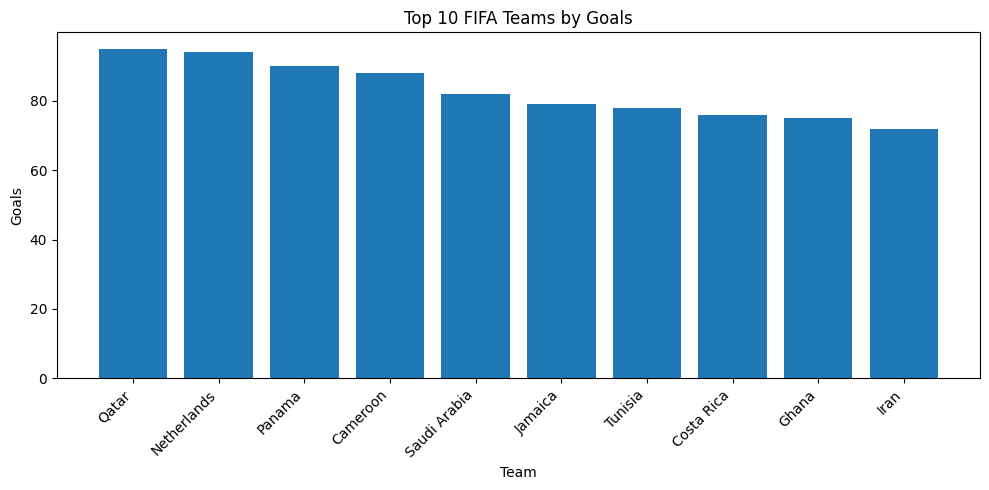

In [6]:
plt.figure(figsize=(10,5)); plt.bar(team_goals["team"],team_goals["goals"]); plt.title("Top 10 FIFA Teams by Goals"); plt.xlabel("Team"); plt.ylabel("Goals"); plt.xticks(rotation=45,ha="right"); plt.tight_layout(); plt.show()

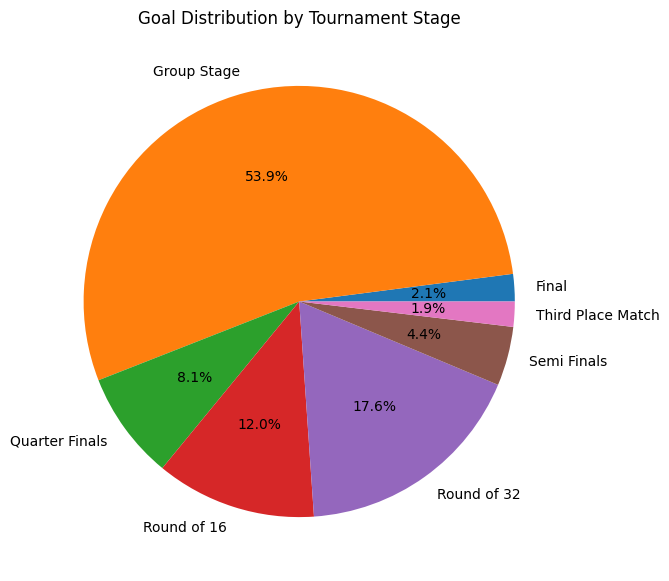

In [7]:
stage_goals=clean.groupby("tournament_stage")["goals"].sum(); plt.figure(figsize=(7,7)); plt.pie(stage_goals.values,labels=stage_goals.index,autopct="%1.1f%%"); plt.title("Goal Distribution by Tournament Stage"); plt.show()

In [8]:
print("DAX Measure examples:"); print("Total Goals = SUM(FIFA[goals])"); print("Total Matches = DISTINCTCOUNT(FIFA[match_id])"); print("Total Players = DISTINCTCOUNT(FIFA[player_id])")

DAX Measure examples:
Total Goals = SUM(FIFA[goals])
Total Matches = DISTINCTCOUNT(FIFA[match_id])
Total Players = DISTINCTCOUNT(FIFA[player_id])
